In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import json

In [4]:
SAMPLE_DIR = Path("samples/ymyl_29000/res_20250723_n100")

# queries_labeled_df = pd.read_csv(SAMPLE_DIR / "_queries_labeled.csv")
responses_df = pd.read_csv(SAMPLE_DIR / "_responses.csv")
classified_urls_df = pd.read_csv(SAMPLE_DIR / "__classified_urls.csv")
unclassified_urls_df = pd.read_csv(SAMPLE_DIR / "__unclassified_urls.csv")

In [5]:
# Filter by category

from ast import literal_eval

queries_df = pd.read_csv("samples/ymyl_29000/queries_ymyl_29000.csv")
print(queries_df.columns)

filtered_query_ids = queries_df[queries_df["ymyl_category"] == "legal"]["query_id"]
# queries_labeled_df = queries_labeled_df[queries_labeled_df["query_id"].isin(filtered_query_ids)]
responses_df = responses_df[responses_df["query_id"].isin(filtered_query_ids)]

def extract_urls(col):
    return col.apply(literal_eval).explode()

references_urls = extract_urls(responses_df["references"])
organic_urls = extract_urls(responses_df["organic_results"])

url_pool = pd.Series(pd.concat([references_urls, organic_urls]).unique(), name="url")

classified_urls_df = classified_urls_df[classified_urls_df["url"].isin(url_pool)]
unclassified_urls_df = unclassified_urls_df[unclassified_urls_df["url"].isin(url_pool)]

Index(['query_id', 'query_text', 'risk_category', 'intent_category',
       'funnel_stage', 'length_category', 'ymyl_category'],
      dtype='object')


In [10]:
from ast import literal_eval

# Explode references
responses_exploded = responses_df[["query_id", "references"]].copy()
responses_exploded["references"] = responses_exploded["references"].apply(literal_eval)
responses_exploded = responses_exploded.explode("references")

# Join with queries to get query text + YMYL category
responses_joined = responses_exploded.merge(
    queries_df[["query_id", "query_text", "ymyl_category"]],
    on="query_id"
)

# Join with high-confidence AI-classified URLs
ai_citations = responses_joined.merge(
    classified_urls_df[(classified_urls_df["ai_class"] == "AI") & (classified_urls_df["confidence"] > 95)],
    left_on="references", right_on="url"
)

# Preview some
print(ai_citations[["query_text", "references", "confidence"]].head(10))
ai_citations[["query_id", "query_text", "ymyl_category", "url", "ai_class", "confidence"]].to_csv("legal_ai_citations.csv", index=False)

                            query_text  \
0  debt to equity conversion agreement   
1           apply for an american visa   
2             visa card business model   
3                 philippines visa usa   
4  how to apply for a new zealand visa   
5  how to apply for a new zealand visa   
6  how to apply for a new zealand visa   
7             what do lawyers do daily   
8             what do lawyers do daily   
9             what do lawyers do daily   

                                          references  confidence  
0  https://realdealdocs.com/what-is-a-debt-conver...       99.99  
1  https://globalconference.ca/how-should-i-prepa...       99.82  
2  https://www.chargeblast.com/blog/how-visa-mast...       98.43  
3  https://evisa-philippines.com/philippines-seam...       99.61  
4  https://www.tataaig.com/travel-insurance/new-z...       99.84  
5  https://www.gokite.travel/common-mistakes-to-a...       97.78  
6  https://www.akbartravels.com/in/visas/new-zeal...       99.78  
7

In [4]:
# print(queries_labeled_df.columns)
print(responses_df.columns)
print(classified_urls_df.columns)
print(unclassified_urls_df.columns)

Index(['query_id', 'references', 'organic_results'], dtype='object')
Index(['url', 'ai_class', 'confidence'], dtype='object')
Index(['url', 'category'], dtype='object')


In [5]:
print("Number of queries:", len(filtered_query_ids))
print("Number of AI Overviews triggered:", len(responses_df))
print("Percentage of AIO:", len(responses_df)/len(filtered_query_ids)*100)
print("")
print("Number of total documents:", len(classified_urls_df) + len(unclassified_urls_df))
print("Number of classified documents:", len(classified_urls_df))
print("Number of unclassified documents:", len(unclassified_urls_df))

Number of queries: 2772
Number of AI Overviews triggered: 196
Percentage of AIO: 7.07070707070707

Number of total documents: 17380
Number of classified documents: 13183
Number of unclassified documents: 4197


In [6]:
def plot_dist_pie(df, col, title=None):
    counts = df[col].value_counts(dropna=False)
    labels = [str(x) for x in counts.index]
    plt.figure(figsize=(4, 4))
    plt.pie(
        counts,
        labels=labels,
        autopct=lambda p: f'{p:.1f}%\n({int(round(p/100.*sum(counts)))})',
        startangle=140
    )
    plt.title(title or f"{col} distribution")
    plt.tight_layout()
    plt.show()

In [7]:
# plot_dist_pie(queries_labeled_df, 'triggered_ai_overview', 'Queries to AI overview (yes/no/blocked)')

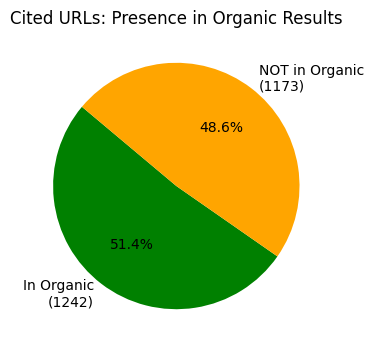

1198
1145
38


In [8]:
in_organic = 0
not_in_organic = 0

organic_set = set()
not_organic_set = set()

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = set(json.loads(row["organic_results"]))
    except Exception:
        continue

    for url in refs:
        if url in organic:
            in_organic += 1
            organic_set.add(url)
        else:
            not_in_organic += 1
            not_organic_set.add(url)

total = in_organic + not_in_organic
values = [in_organic, not_in_organic]
labels = [
    f"In Organic\n({in_organic})",
    f"NOT in Organic\n({not_in_organic})"
]

plt.figure(figsize=(4, 4))
plt.pie(
    values,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%',
    colors=["green", "orange"],
    startangle=140
)
plt.title("Cited URLs: Presence in Organic Results")
plt.show()

print(len(organic_set))
print(len(not_organic_set))
print(len(organic_set & not_organic_set))

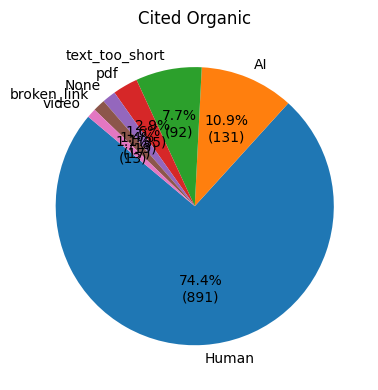

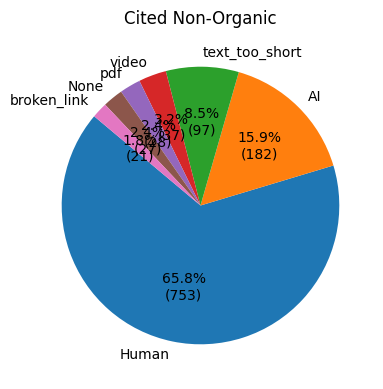

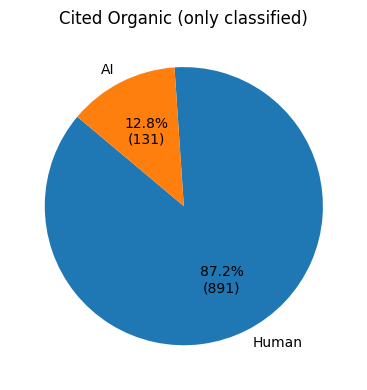

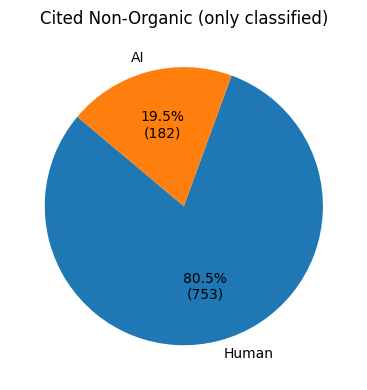

In [9]:
def build_category_df(url_set, classified_df, unclassified_df):
    # Create lookup dictionaries
    classified_lookup = dict(zip(classified_df["url"], classified_df["ai_class"]))
    unclassified_lookup = dict(zip(unclassified_df["url"], unclassified_df["category"]))

    # Build list of rows
    rows = []
    for url in url_set:
        if url in classified_lookup:
            category = classified_lookup[url]
        elif url in unclassified_lookup:
            category = unclassified_lookup[url]
        else:
            category = None
        rows.append((url, category))

    return pd.DataFrame(rows, columns=["url", "category"])

# Create the two DataFrames
organic_df = build_category_df(organic_set, classified_urls_df, unclassified_urls_df)
not_organic_df = build_category_df(not_organic_set, classified_urls_df, unclassified_urls_df)

plot_dist_pie(organic_df, 'category', 'Cited Organic')
plot_dist_pie(not_organic_df, 'category', 'Cited Non-Organic')

# Filter to keep only rows with category "AI" or "Human"
organic_df_filtered = organic_df[organic_df["category"].isin(["AI", "Human"])]
not_organic_df_filtered = not_organic_df[not_organic_df["category"].isin(["AI", "Human"])]

# Plot filtered pies
plot_dist_pie(organic_df_filtered, 'category', 'Cited Organic (only classified)')
plot_dist_pie(not_organic_df_filtered, 'category', 'Cited Non-Organic (only classified)')

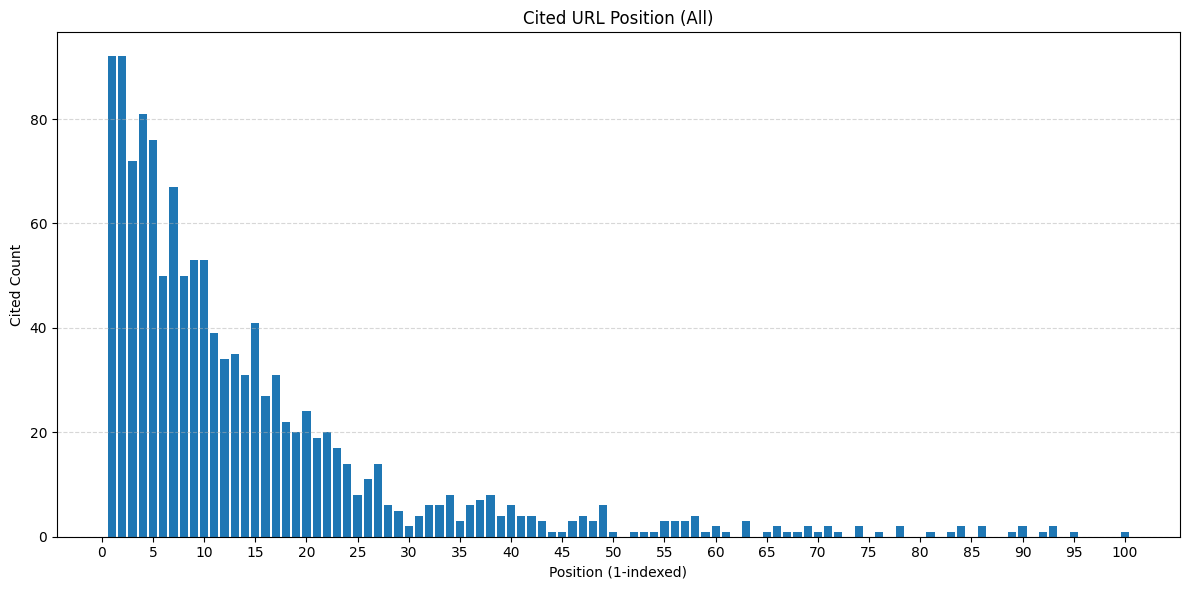

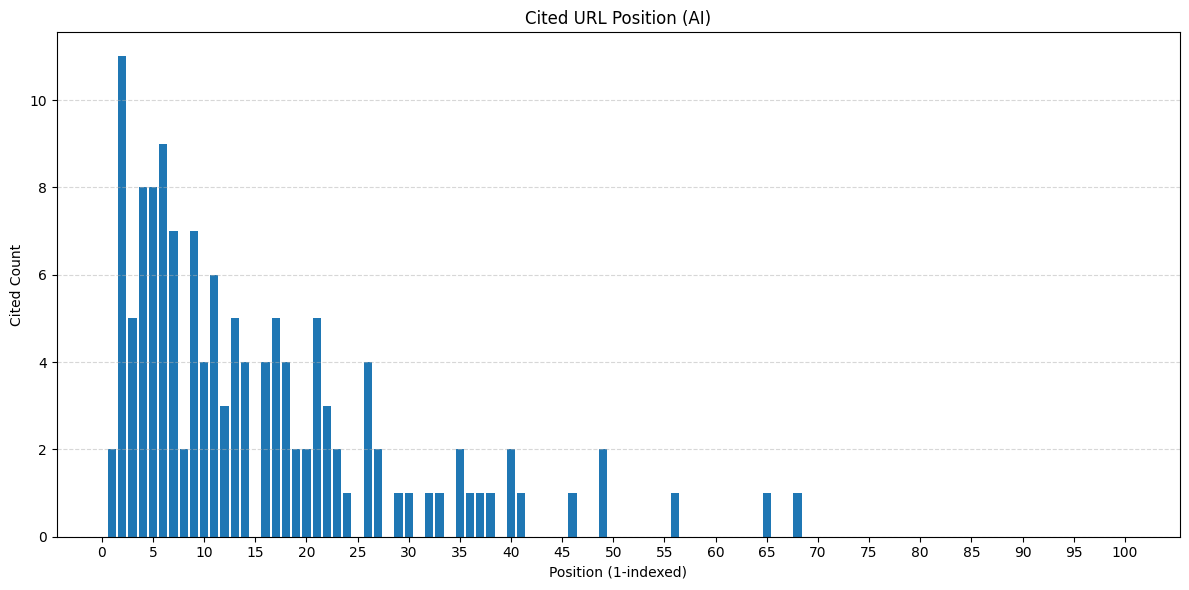

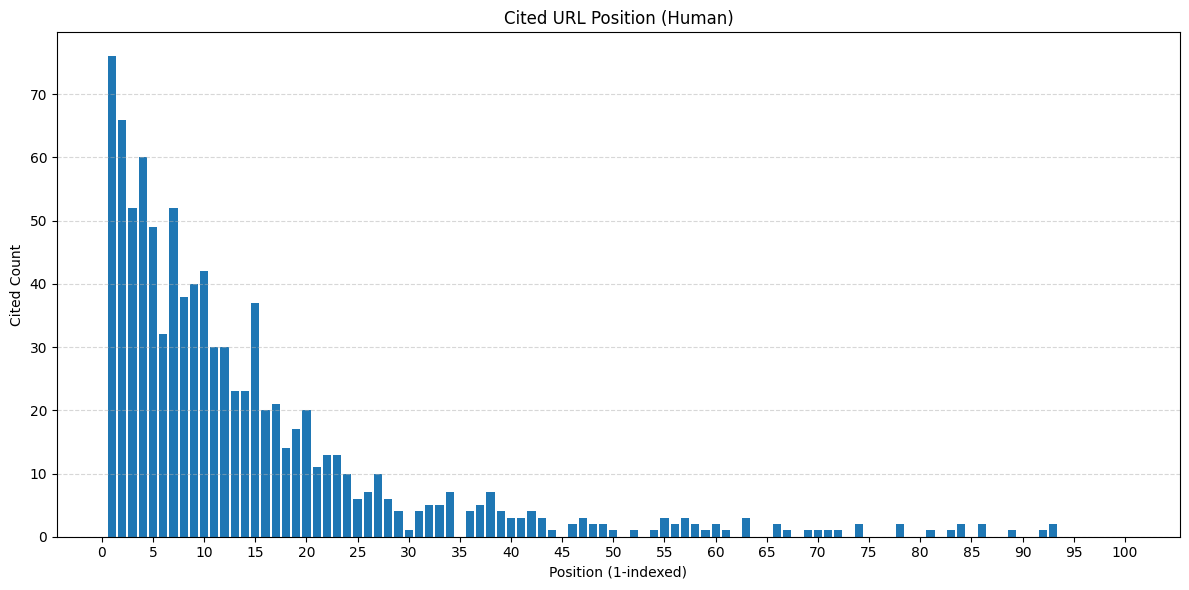

In [10]:
def plot_cited_positions(responses_df, label=None):
    position_counter = Counter()

    for _, row in responses_df.iterrows():
        try:
            refs = set(json.loads(row["references"]))
            organic = json.loads(row["organic_results"])
        except Exception:
            continue

        for i, url in enumerate(organic):
            if url in refs:
                if label is None:
                    position_counter[i + 1] += 1
                else:
                    if label == "AI" and url in set(classified_urls_df[classified_urls_df["ai_class"] == "AI"]["url"]):
                        position_counter[i + 1] += 1
                    elif label == "Human" and url in set(classified_urls_df[classified_urls_df["ai_class"] == "Human"]["url"]):
                        position_counter[i + 1] += 1

    positions = list(range(1, 101))
    counts = [position_counter.get(i, 0) for i in positions]

    plt.figure(figsize=(12, 6))
    plt.bar(positions, counts)
    title = "Cited URL Position"
    if label:
        title += f" ({label})"
    else:
        title += " (All)"
    plt.title(title)
    plt.xlabel("Position (1-indexed)")
    plt.ylabel("Cited Count")
    plt.xticks(range(0, 101, 5))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_cited_positions(responses_df)
plot_cited_positions(responses_df, "AI")
plot_cited_positions(responses_df, "Human")

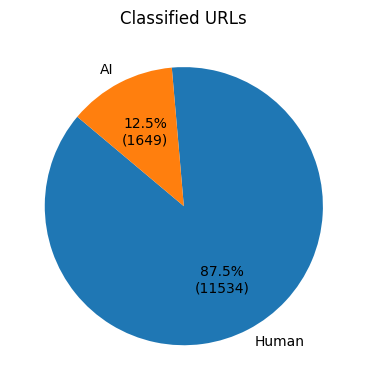

In [11]:
plot_dist_pie(classified_urls_df, 'ai_class', 'Classified URLs')

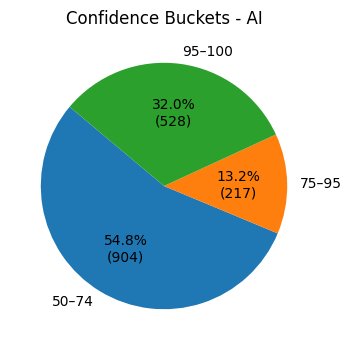

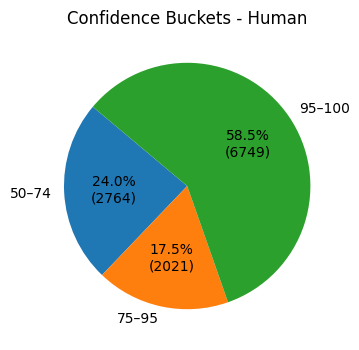

In [12]:
# Group into confidence buckets
def bucket(conf):
    if conf >= 95:
        return "95–100"
    elif conf >= 75:
        return "75–95"
    elif conf >= 50:
        return "50–74"
    else:
        return "<50"

# Apply bucket function
classified_urls_df["conf_bucket"] = classified_urls_df["confidence"].apply(bucket)

# Separate into two groups
ai_df = classified_urls_df[classified_urls_df["ai_class"] == "AI"]
human_df = classified_urls_df[classified_urls_df["ai_class"] == "Human"]

# Get counts
ai_counts = ai_df["conf_bucket"].value_counts().sort_index()
human_counts = human_df["conf_bucket"].value_counts().sort_index()

# Plot AI pie
plt.figure(figsize=(4, 4))
plt.pie(
    ai_counts,
    labels=ai_counts.index,
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct/100.*sum(ai_counts)))})',
    startangle=140
)
plt.title("Confidence Buckets - AI")
plt.show()

# Plot Human pie
plt.figure(figsize=(4, 4))
plt.pie(
    human_counts,
    labels=human_counts.index,
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct/100.*sum(human_counts)))})',
    startangle=140
)
plt.title("Confidence Buckets - Human")
plt.show()

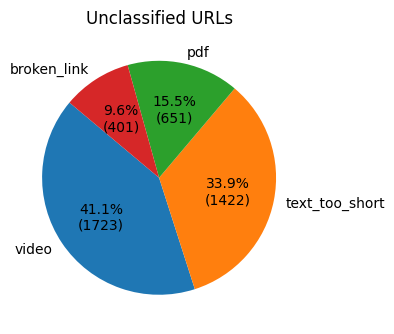

In [13]:
plot_dist_pie(unclassified_urls_df, 'category', 'Unclassified URLs')

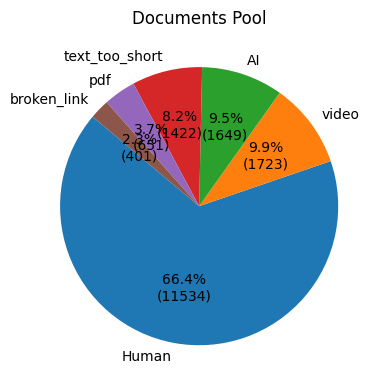

In [14]:
merged_df = pd.concat([
    classified_urls_df[['url']].assign(category=classified_urls_df['ai_class']),
    unclassified_urls_df[['url']].assign(category=unclassified_urls_df['category'])
], ignore_index=True)

plot_dist_pie(merged_df, 'category', 'Documents Pool')

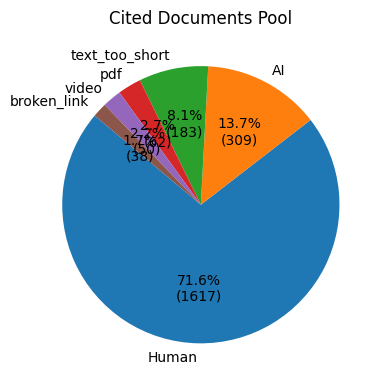

In [15]:
import ast

# Safe temporary copies — no modification to originals
classified_temp = classified_urls_df[["url", "ai_class"]].copy()
classified_temp = classified_temp.rename(columns={"ai_class": "category"})

unclassified_temp = unclassified_urls_df[["url", "category"]].copy()

merged_df = pd.concat([classified_temp, unclassified_temp], ignore_index=True).drop_duplicates(subset="url", keep="last")

# Safely extract normalized cited URLs without modifying responses_df
cited_urls = set()
for refs in responses_df["references"]:
    try:
        parsed = ast.literal_eval(refs) if pd.notnull(refs) else []
        cited_urls.update(url.strip().lower().rstrip('/') for url in parsed)
    except Exception:
        pass

# Normalize merged URLs for matching (but don't touch original DataFrames)
merged_df_temp = merged_df.copy()
merged_df_temp["url"] = merged_df_temp["url"].str.strip().str.lower().str.rstrip('/')

cited_df = merged_df_temp[merged_df_temp["url"].isin(cited_urls)].reset_index(drop=True)

plot_dist_pie(cited_df, 'category', 'Cited Documents Pool')

## By unique document

In [20]:
# Define classified sets
ai_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "AI"]["url"])
human_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "Human"]["url"])

# Define citation sets
cited_urls = set()
cited_from_organic_urls = set()

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = set(json.loads(row["organic_results"]))
        cited_urls.update(refs)
        cited_from_organic_urls.update(refs & organic)
    except Exception:
        continue

# Totals
ai_total = len(ai_urls)
human_total = len(human_urls)

# AI stats
ai_cited = len(cited_urls & ai_urls)
ai_cited_from_organic = len(cited_from_organic_urls & ai_urls)
ai_cited_outside_organic = ai_cited - ai_cited_from_organic

# Human stats
human_cited = len(cited_urls & human_urls)
human_cited_from_organic = len(cited_from_organic_urls & human_urls)
human_cited_outside_organic = human_cited - human_cited_from_organic

# Probabilities (safeguarded)
p_ai_cited = ai_cited / ai_total if ai_total else 0
p_ai_cited_from_organic = ai_cited_from_organic / ai_total if ai_total else 0
p_ai_cited_outside_organic = ai_cited_outside_organic / ai_total if ai_total else 0

p_human_cited = human_cited / human_total if human_total else 0
p_human_cited_from_organic = human_cited_from_organic / human_total if human_total else 0
p_human_cited_outside_organic = human_cited_outside_organic / human_total if human_total else 0

# Output
print("P(cited | AI):", f"{p_ai_cited * 100:.2f}%")
print("P(cited-from-organic | AI):", f"{p_ai_cited_from_organic * 100:.2f}%")
print("P(cited-out-of-organic | AI):", f"{p_ai_cited_outside_organic * 100:.2f}%")
print()
print("P(cited | Human):", f"{p_human_cited * 100:.2f}%")
print("P(cited-from-organic | Human):", f"{p_human_cited_from_organic * 100:.2f}%")
print("P(cited-out-of-organic | Human):", f"{p_human_cited_outside_organic * 100:.2f}%")


P(cited | AI): 18.74%
P(cited-from-organic | AI): 7.94%
P(cited-out-of-organic | AI): 10.79%

P(cited | Human): 14.02%
P(cited-from-organic | Human): 7.72%
P(cited-out-of-organic | Human): 6.29%


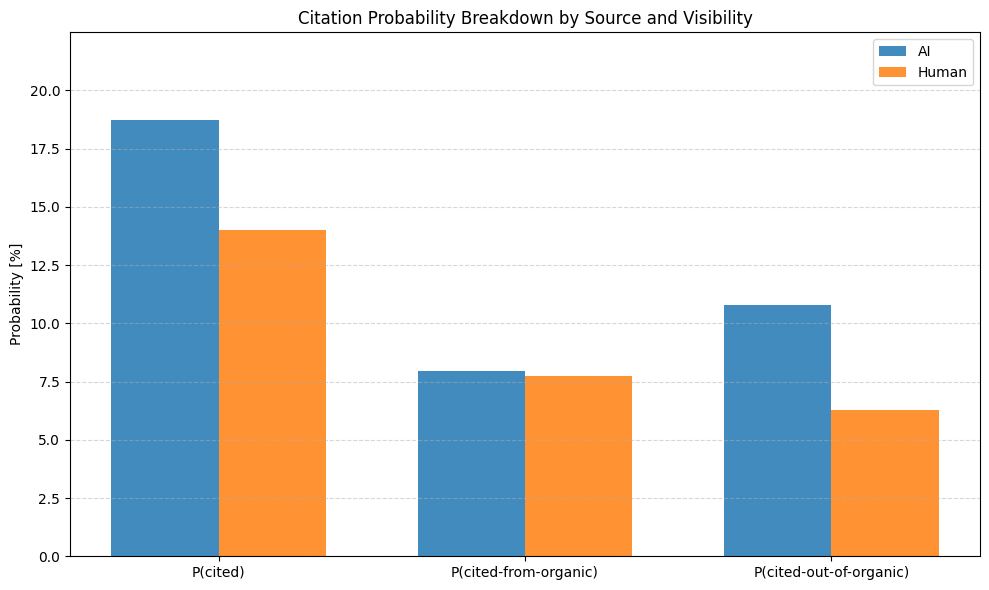

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Data
labels = ['P(cited)', 'P(cited-from-organic)', 'P(cited-out-of-organic)']
ai_values = [
    p_ai_cited * 100,
    p_ai_cited_from_organic * 100,
    p_ai_cited_outside_organic * 100,
]
human_values = [
    p_human_cited * 100,
    p_human_cited_from_organic * 100,
    p_human_cited_outside_organic * 100,
]

x = np.arange(len(labels))  # label locations
width = 0.35  # bar width

# Plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, ai_values, width, label='AI', alpha=0.85)
plt.bar(x + width/2, human_values, width, label='Human', alpha=0.85)

# Labels and styling
plt.ylabel('Probability [%]')
plt.title('Citation Probability Breakdown by Source and Visibility')
plt.xticks(x, labels)
plt.ylim(0, max(ai_values + human_values) * 1.2)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## By Google result appearance

P(cited-from-organic | AI & in-top-k)

P(cited-from-organic | Human & in-top-k)

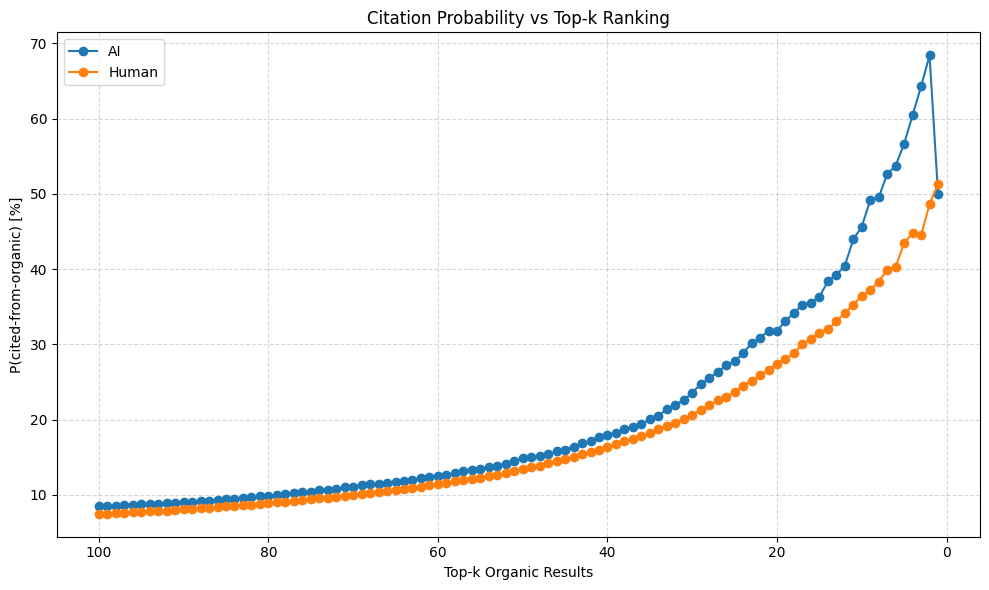


Selected citation probabilities:

Top-  1: AI 50.00% vs Human 51.35% ( 1.35)
Top-  5: AI 56.67% vs Human 43.47% (13.19)
Top- 10: AI 45.65% vs Human 36.45% ( 9.20)
Top- 20: AI 31.82% vs Human 27.45% ( 4.37)
Top- 30: AI 23.59% vs Human 20.68% ( 2.91)
Top- 50: AI 14.91% vs Human 13.43% ( 1.48)
Top-100: AI  8.50% vs Human  7.50% ( 1.00)


In [18]:
cutoffs = list(range(1, 101))
p_ai_list = []
p_human_list = []

ai_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "AI"]["url"])
human_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "Human"]["url"])

for k in cutoffs:
    ai_total = ai_cited = human_total = human_cited = 0

    for _, row in responses_df.iterrows():
        try:
            refs = set(json.loads(row["references"]))
            organic = json.loads(row["organic_results"])[:k]
        except Exception:
            continue

        for url in organic:
            if url in ai_urls:
                ai_total += 1
                if url in refs:
                    ai_cited += 1
            elif url in human_urls:
                human_total += 1
                if url in refs:
                    human_cited += 1

    p_ai = ai_cited / ai_total if ai_total else 0
    p_human = human_cited / human_total if human_total else 0

    # print(ai_total)

    p_ai_list.append(p_ai * 100)
    p_human_list.append(p_human * 100)

plt.figure(figsize=(10, 6))
plt.plot(cutoffs, p_ai_list, marker='o', label="AI")
plt.plot(cutoffs, p_human_list, marker='o', label="Human")
plt.xlabel("Top-k Organic Results")
plt.ylabel("P(cited-from-organic) [%]")
plt.title("Citation Probability vs Top-k Ranking")
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Display selected cutoff probabilities
key_cutoffs = [1, 5, 10, 20, 30, 50, 100]
print("\nSelected citation probabilities:\n")
for k in key_cutoffs:
    ai_val = p_ai_list[k - 1]
    human_val = p_human_list[k - 1]
    print(f"Top-{k:3d}: AI {ai_val:5.2f}% vs Human {human_val:5.2f}% ({abs(ai_val - human_val):5.2f})")


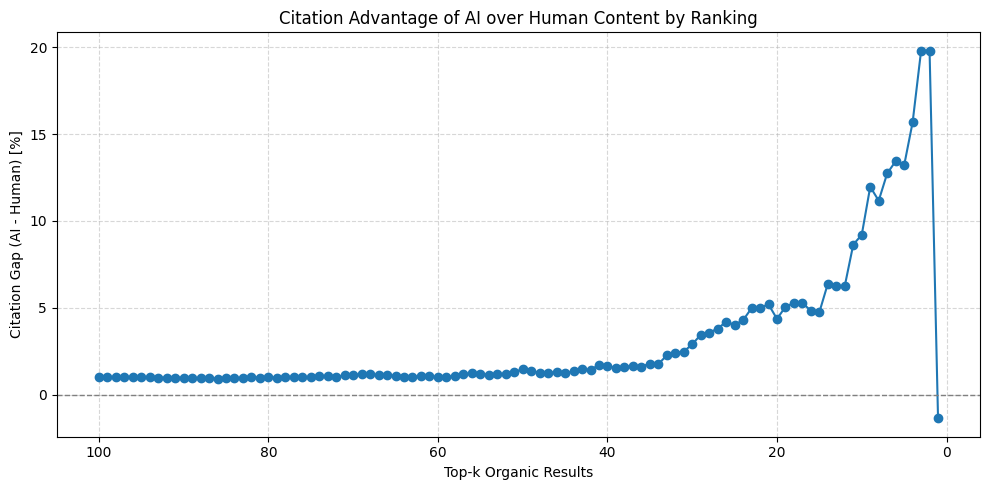

In [19]:
# Calculate the gap (AI - Human) at each k
gap_list = [ai - human for ai, human in zip(p_ai_list, p_human_list)]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(cutoffs, gap_list, marker='o')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Top-k Organic Results")
plt.ylabel("Citation Gap (AI - Human) [%]")
plt.title("Citation Advantage of AI over Human Content by Ranking")
plt.gca().invert_xaxis()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
